## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Una matriz de NumPy de 5×5 que representa la imagen capturada por la cámara, donde cada celda vale 0 (píxel normal) o 1 (píxel defectuoso) |
| **Acciones (A)** | Aprobar el producto / Enviarlo a revisión manual / Rechazarlo y retirarlo de la línea |
| **Entorno (E)** | Una línea de producción en movimiento continuo, con iluminación que puede variar, productos que pasan uno tras otro y una cámara fija que captura cada pieza |
| **Objetivo** | Impedir que un producto defectuoso llegue al cliente, sin descartar piezas que en realidad están en buen estado |
| **Medida de desempeño (P)** | Cantidad de defectuosos detectados, número de productos buenos rechazados por error, piezas derivadas a revisión manual y ritmo de inspección sostenido |

### Justificación de las reglas

Los umbrales responden a que no todo defecto tiene el mismo peso: una pieza completamente limpia
puede pasar sin intervención humana, mientras que una con daño extendido no merece ni siquiera el
costo de revisarla. La franja de 1 a 3 píxeles es la zona ambigua, donde el defecto puede ser real
o un artefacto de la cámara (una sombra, una mota de polvo, un reflejo), y donde equivocarse en
cualquier dirección sale caro. Por eso ahí no se decide automáticamente sino que se deriva a una
persona: la revisión manual es más lenta, pero evita tanto botar producto bueno como dejar pasar
producto malo en los casos donde la evidencia no alcanza para resolver por sí sola.

**Reglas:**

| Píxeles defectuosos | Decisión |
|---|---|
| 0 | Aprobar |
| 1 a 3 | Enviar a revisión manual |
| Más de 3 | Rechazar |

### Código

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Agente reactivo simple para inspeccion visual en linea de produccion.
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso).
    Acciones (A): aprobar, enviar a revision manual, rechazar.
    Retorna una tupla (accion, motivo).
    """
    defectos = int(np.sum(imagen == 1))

    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos, requiere verificacion humana"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos, dano extendido"


# Imagen de prueba del enunciado (3 defectos)
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])

print(agente_inspeccion(imagen_prueba))

('revision manual', 'se detectaron 3 pixeles defectuosos, requiere verificacion humana')


### Simulación y pruebas

Sin defectos: APROBAR -> no se detectaron pixeles defectuosos
Un defecto: REVISION MANUAL -> se detectaron 1 pixeles defectuosos, requiere verificacion humana
Limite: 3 defectos: REVISION MANUAL -> se detectaron 3 pixeles defectuosos, requiere verificacion humana
Limite: 4 defectos: RECHAZAR -> se detectaron 4 pixeles defectuosos, dano extendido
Dano extendido: RECHAZAR -> se detectaron 11 pixeles defectuosos, dano extendido


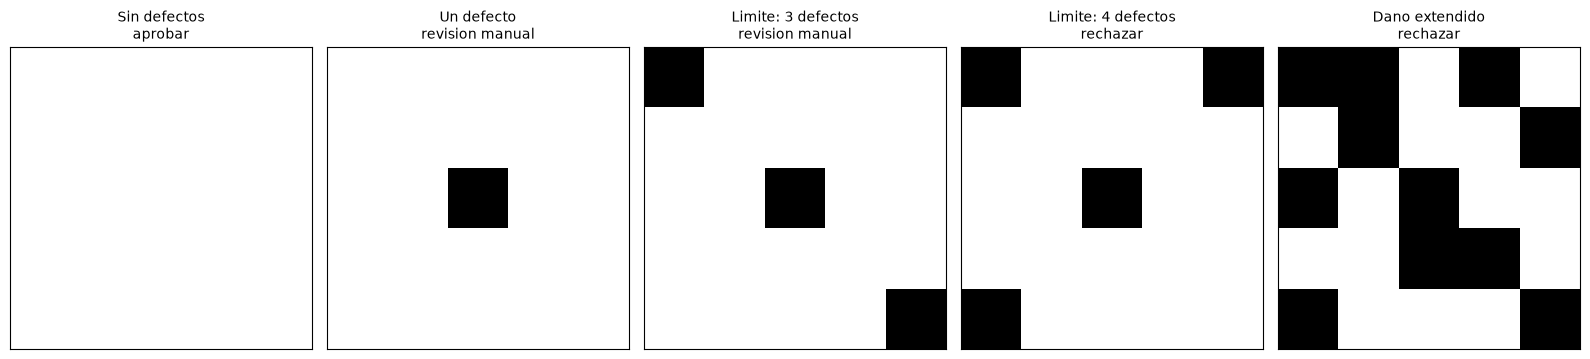

In [2]:
import matplotlib.pyplot as plt

# Caso 1: producto sin defectos
imagen_limpia = np.zeros((5, 5), dtype=int)

# Caso 2: un solo defecto (inicio de la zona ambigua)
imagen_un_defecto = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

# Caso 3: CASO LIMITE con 3 defectos (ultimo valor antes del rechazo)
imagen_limite = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],
])

# Caso 4: CASO LIMITE con 4 defectos (primer valor que ya se rechaza)
imagen_rechazo = np.array([
    [1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
])

# Caso 5: dano extendido
imagen_danada = np.array([
    [1, 1, 0, 1, 0],
    [0, 1, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [1, 0, 0, 0, 1],
])

muestras = [
    ("Sin defectos", imagen_limpia),
    ("Un defecto", imagen_un_defecto),
    ("Limite: 3 defectos", imagen_limite),
    ("Limite: 4 defectos", imagen_rechazo),
    ("Dano extendido", imagen_danada),
]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, (nombre, img) in zip(axes, muestras):
    accion, motivo = agente_inspeccion(img)
    print(f"{nombre}: {accion.upper()} -> {motivo}")

    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"{nombre}\n{accion}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()